In [1]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from pathlib import Path

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split

# Reproducibility

SEED = 42
np.random.seed(SEED)

In [2]:
!gdown --id 1xFDvCOLa_gu34CosX8kSCIqqhD-E2te8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xFDvCOLa_gu34CosX8kSCIqqhD-E2te8
To: /content/sales_prediction.csv
100% 870k/870k [00:00<00:00, 53.8MB/s]


In [3]:
df=pd.read_csv('/content/sales_prediction.csv')

In [4]:


print("\nData Types\n")

print(df.dtypes)

print("\nMissing Values\n")

print(df.isnull().sum())

print("\nDuplicate Rows")

print(df.duplicated().sum())


Data Types

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

Missing Values

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Duplicate Rows
0


In [5]:


TARGET = "Item_Outlet_Sales"

print(df[TARGET].describe())

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


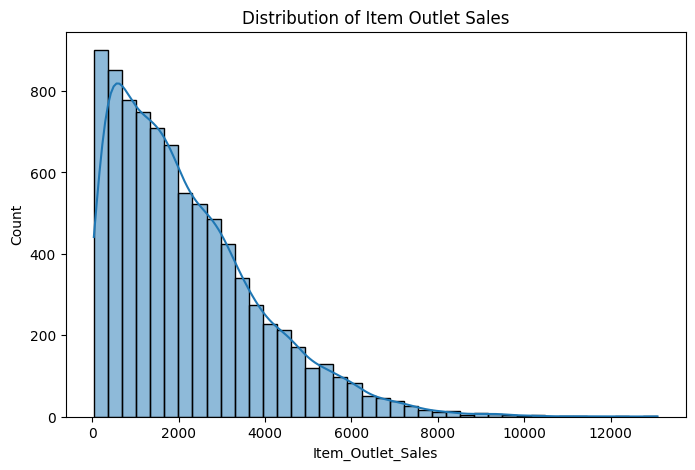

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[TARGET],
    bins=40,
    kde=True
)

plt.title("Distribution of Item Outlet Sales")

plt.show()

In [7]:


X = df.drop(columns=[TARGET])

y = df[TARGET]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (8523, 11)
Target Shape : (8523,)


In [8]:


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=SEED

)

print()

print("Training Shape")

print(X_train.shape)

print()

print("Testing Shape")

print(X_test.shape)


Training Shape
(6818, 11)

Testing Shape
(1705, 11)


In [9]:

print("\nMissing Values in Training Data")
print(X_train.isnull().sum())


Missing Values in Training Data
Item_Identifier                 0
Item_Weight                  1174
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1935
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64


Fill Missing Item_Weight

In [10]:


item_weight_map = X_train.groupby("Item_Identifier")["Item_Weight"].median()

X_train["Item_Weight"] = X_train.apply(
    lambda row: item_weight_map[row["Item_Identifier"]]
    if pd.isna(row["Item_Weight"])
    else row["Item_Weight"],
    axis=1,
)

X_train["Item_Weight"].fillna(
    X_train["Item_Weight"].median(),
    inplace=True
)

In [11]:
X_test["Item_Weight"] = X_test.apply(
    lambda row: item_weight_map.get(
        row["Item_Identifier"],
        X_train["Item_Weight"].median(),
    )
    if pd.isna(row["Item_Weight"])
    else row["Item_Weight"],
    axis=1,
)

# fill Missing Outlet_Size

In [12]:


outlet_size_map = (
    X_train.groupby("Outlet_Type")["Outlet_Size"]
    .agg(lambda x: x.mode()[0])
)

X_train["Outlet_Size"] = X_train.apply(
    lambda row: outlet_size_map[row["Outlet_Type"]]
    if pd.isna(row["Outlet_Size"])
    else row["Outlet_Size"],
    axis=1,
)

In [13]:
X_test["Outlet_Size"] = X_test.apply(
    lambda row: outlet_size_map.get(
        row["Outlet_Type"],
        X_train["Outlet_Size"].mode()[0],
    )
    if pd.isna(row["Outlet_Size"])
    else row["Outlet_Size"],
    axis=1,
)

Fix Item_Fat_Content

In [14]:


fat_map = {
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
}

X_train["Item_Fat_Content"] = X_train["Item_Fat_Content"].replace(fat_map)

X_test["Item_Fat_Content"] = X_test["Item_Fat_Content"].replace(fat_map)

Fix Zero Visibility

In [15]:


X_train["Item_Visibility"] = X_train["Item_Visibility"].replace(0, np.nan)

visibility_map = X_train.groupby("Item_Identifier")[
    "Item_Visibility"
].mean()

X_train["Item_Visibility"] = X_train.apply(
    lambda row: visibility_map[row["Item_Identifier"]]
    if pd.isna(row["Item_Visibility"])
    else row["Item_Visibility"],
    axis=1,
)

X_train["Item_Visibility"].fillna(
    X_train["Item_Visibility"].median(),
    inplace=True
)

In [16]:
X_test["Item_Visibility"] = X_test.apply(
    lambda row: visibility_map.get(
        row["Item_Identifier"],
        X_train["Item_Visibility"].median(),
    )
    if pd.isna(row["Item_Visibility"])
    else row["Item_Visibility"],
    axis=1,
)

Create Outlet Age

In [17]:


CURRENT_YEAR = 2026

X_train["Outlet_Age"] = (
    CURRENT_YEAR - X_train["Outlet_Establishment_Year"]
)

X_test["Outlet_Age"] = (
    CURRENT_YEAR - X_test["Outlet_Establishment_Year"]
)

Create Item Category

In [18]:


category_map = {
    "FD": "Food",
    "DR": "Drinks",
    "NC": "Non-Consumable",
}

X_train["Item_Category"] = (
    X_train["Item_Identifier"]
    .str[:2]
    .map(category_map)
)

X_test["Item_Category"] = (
    X_test["Item_Identifier"]
    .str[:2]
    .map(category_map)
)

Non-Consumables

In [19]:

X_train.loc[
    X_train["Item_Category"] == "Non-Consumable",
    "Item_Fat_Content",
] = "Non-Edible"

X_test.loc[
    X_test["Item_Category"] == "Non-Consumable",
    "Item_Fat_Content",
] = "Non-Edible"

In [20]:
print(X_train.head())

print("\nShape :", X_train.shape)

     Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
549            FDW44        9.500          Regular         0.035206   
7757           NCF54       18.000       Non-Edible         0.047473   
764            FDY03       17.600          Regular         0.076122   
6867           FDQ20        8.325          Low Fat         0.029845   
2716           FDP34       12.850          Low Fat         0.137228   

                  Item_Type  Item_MRP Outlet_Identifier  \
549   Fruits and Vegetables  171.3448            OUT049   
7757              Household  170.5422            OUT045   
764                    Meat  111.7202            OUT046   
6867  Fruits and Vegetables   41.6138            OUT045   
2716            Snack Foods  155.5630            OUT046   

      Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
549                        1999      Medium               Tier 1   
7757                       2002       Small               Tier 2   
764           

In [21]:

# Preprocessing Pipeline


from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OrdinalEncoder

from sklearn.impute import SimpleImputer

In [22]:

# Drop Item Identifier

X_train = X_train.drop(columns=["Item_Identifier"])

X_test = X_test.drop(columns=["Item_Identifier"])

print(X_train.shape)

(6818, 12)


In [23]:


numerical_features = [

    "Item_Weight",

    "Item_Visibility",

    "Item_MRP",

    "Outlet_Establishment_Year",

    "Outlet_Age"

]

print(numerical_features)

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Age']


In [24]:


categorical_features = [

    "Item_Fat_Content",

    "Item_Type",

    "Outlet_Identifier",

    "Outlet_Size",

    "Outlet_Location_Type",

    "Outlet_Type",

    "Item_Category"

]

print(categorical_features)

['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']


In [25]:
# ==========================================================
# Numerical Pipeline
# ==========================================================

numeric_pipeline = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(strategy="median")

        )

    ]

)

In [26]:
# ==========================================================
# Categorical Pipeline
# ==========================================================

categorical_pipeline = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(

                strategy="most_frequent"

            )

        ),

        (

            "encoder",

            OrdinalEncoder(

                handle_unknown="use_encoded_value",

                unknown_value=-1

            )

        )

    ]

)

In [27]:
# ==========================================================
# Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_pipeline,

            numerical_features

        ),

        (

            "cat",

            categorical_pipeline,

            categorical_features

        )

    ],

    remainder="drop"

)

In [28]:
# ==========================================================
# Test Preprocessing
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape :", X_train_processed.shape)

print("Processed Test Shape :", X_test_processed.shape)

Processed Train Shape : (6818, 12)
Processed Test Shape : (1705, 12)


In [29]:
import joblib

joblib.dump(

    preprocessor,

    "preprocessor.pkl"

)

print("Preprocessor Saved Successfully")

Preprocessor Saved Successfully


In [30]:


from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import time

In [31]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(model, X_train, X_test, y_train, y_test):

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    print("="*60)

    print("Train RMSE :", round(train_rmse,2))
    print("Test RMSE  :", round(test_rmse,2))

    print()

    print("Train MAE :", round(train_mae,2))
    print("Test MAE  :", round(test_mae,2))

    print()

    print("Train R2 :", round(train_r2,4))
    print("Test R2  :", round(test_r2,4))

    print("="*60)

    return {

        "Train RMSE":train_rmse,

        "Test RMSE":test_rmse,

        "Train MAE":train_mae,

        "Test MAE":test_mae,

        "Train R2":train_r2,

        "Test R2":test_r2

    }

In [32]:
# ==========================================================
# Generic Training Function
# ==========================================================

def train_model(

        model,

        param_grid,

        model_name

):

    pipeline = Pipeline(

        [

            ("preprocessor",preprocessor),

            ("model",model)

        ]

    )

    search = RandomizedSearchCV(

        estimator=pipeline,

        param_distributions=param_grid,

        n_iter=20,

        cv=5,

        scoring="neg_root_mean_squared_error",

        random_state=SEED,

        verbose=2,

        n_jobs=-1

    )

    start = time.time()

    search.fit(

        X_train,

        y_train

    )

    end = time.time()

    print()

    print("="*60)

    print(model_name)

    print("="*60)

    print()

    print("Best Parameters")

    print(search.best_params_)

    print()

    print("Training Time")

    print(round(end-start,2),"seconds")

    print()

    scores = evaluate_model(

        search.best_estimator_,

        X_train,

        X_test,

        y_train,

        y_test

    )

    joblib.dump(

        search.best_estimator_,

        f"{model_name}.pkl"

    )

    print()

    print(model_name,"saved successfully.")

    return {

        "Model":model_name,

        "Pipeline":search.best_estimator_,

        "Score":scores,

        "Best Params":search.best_params_

    }

In [33]:
# ==========================================================
# Store Results
# ==========================================================

results = []

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    random_state=SEED

)

rf_params = {

    "model__n_estimators":[100,200,300,500],

    "model__max_depth":[10,15,20,None],

    "model__min_samples_split":[2,5,10],

    "model__min_samples_leaf":[1,2,4],

    "model__max_features":["sqrt","log2"]

}

rf_results = train_model(

    rf,

    rf_params,

    "RandomForest"

)

results.append(rf_results)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomForest

Best Parameters
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10}

Training Time
205.71 seconds

Train RMSE : 991.35
Test RMSE  : 1029.98

Train MAE : 702.95
Test MAE  : 730.51

Train R2 : 0.6678
Test R2  : 0.6097

RandomForest saved successfully.


In [36]:
# ==========================================================
# Gradient Boosting Regressor
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=SEED
)

gbr_params = {

    "model__n_estimators":[100,200,300,500],

    "model__learning_rate":[0.01,0.05,0.1,0.2],

    "model__max_depth":[2,3,4,5],

    "model__min_samples_split":[2,5,10],

    "model__min_samples_leaf":[1,2,4],

    "model__subsample":[0.7,0.8,0.9,1.0]

}

gbr_results = train_model(

    model=gbr,

    param_grid=gbr_params,

    model_name="GradientBoosting"

)

results.append(gbr_results)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

GradientBoosting

Best Parameters
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.05}

Training Time
271.76 seconds

Train RMSE : 1064.67
Test RMSE  : 1024.95

Train MAE : 751.64
Test MAE  : 719.32

Train R2 : 0.6168
Test R2  : 0.6135

GradientBoosting saved successfully.


In [37]:
# ==========================================================
# XGBoost Regressor
# ==========================================================

from xgboost import XGBRegressor

xgb = XGBRegressor(

    objective="reg:squarederror",

    random_state=SEED,

    tree_method="hist",

    eval_metric="rmse"

)

xgb_params = {

    "model__n_estimators":[200,300,500,700],

    "model__learning_rate":[0.01,0.03,0.05,0.1],

    "model__max_depth":[3,4,5,6,8],

    "model__subsample":[0.7,0.8,0.9,1.0],

    "model__colsample_bytree":[0.7,0.8,0.9,1.0],

    "model__gamma":[0,0.1,0.2,0.3],

    "model__min_child_weight":[1,3,5],

    "model__reg_alpha":[0,0.01,0.1],

    "model__reg_lambda":[1,2,5]

}

xgb_results = train_model(

    model=xgb,

    param_grid=xgb_params,

    model_name="XGBoost"

)

results.append(xgb_results)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

XGBoost

Best Parameters
{'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}

Training Time
43.81 seconds

Train RMSE : 1062.59
Test RMSE  : 1020.81

Train MAE : 747.3
Test MAE  : 716.18

Train R2 : 0.6183
Test R2  : 0.6166

XGBoost saved successfully.


In [38]:
# ==========================================================
# Compare Models
# ==========================================================

comparison = pd.DataFrame([

    {

        "Model": r["Model"],

        "Train RMSE": r["Score"]["Train RMSE"],

        "Test RMSE": r["Score"]["Test RMSE"],

        "Train MAE": r["Score"]["Train MAE"],

        "Test MAE": r["Score"]["Test MAE"],

        "Train R2": r["Score"]["Train R2"],

        "Test R2": r["Score"]["Test R2"]

    }

    for r in results

])

comparison = comparison.sort_values(
    by="Test RMSE",
    ascending=True
)

print(comparison)

comparison

              Model   Train RMSE    Test RMSE   Train MAE    Test MAE  \
2           XGBoost  1062.594194  1020.807470  747.299307  716.181941   
1  GradientBoosting  1064.670274  1024.946060  751.643395  719.324041   
0      RandomForest   991.346882  1029.982912  702.951433  730.508505   

   Train R2   Test R2  
2  0.618294  0.616608  
1  0.616801  0.613493  
0  0.667765  0.609685  


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
2,XGBoost,1062.594194,1020.807470,747.299307,716.181941,0.618294,0.616608
1,GradientBoosting,1064.670274,1024.946060,751.643395,719.324041,0.616801,0.613493
0,RandomForest,991.346882,1029.982912,702.951433,730.508505,0.667765,0.609685


In [39]:
# ==========================================================
# Save Best Model
# ==========================================================

best_model = min(
    results,
    key=lambda x: x["Score"]["Test RMSE"]
)

joblib.dump(

    best_model["Pipeline"],

    "sales_pipeline.pkl"

)

print("="*60)
print("Best Model :", best_model["Model"])
print("Pipeline Saved Successfully")
print("="*60)

Best Model : XGBoost
Pipeline Saved Successfully


In [40]:
# Test Saved Pipeline

pipeline = joblib.load("sales_pipeline.pkl")

prediction = pipeline.predict(X_test.iloc[:5])

print(prediction)

[1311.5337   689.5201   727.25195 4801.2715  3306.948  ]


SyntaxError: invalid syntax (1854685337.py, line 1)